<a href="https://colab.research.google.com/github/bygencer3/ErdincGencer_Odev_254329028-/blob/main/254329028_Erdinc_Gencer_Makine_Ogrenmesi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
# =====================================================================
# HÜCRE 1: KÜTÜPHANELER VE VERİ OKUMA (AKADEMİK STANDART)
# =====================================================================

# 1. Gerekli kütüphanelerin kurulumu
!pip install optuna -q

# 2. Temel kütüphanelerin import edilmesi
import os
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# İstatistiksel analiz ve makine öğrenmesi kütüphaneleri
import optuna
from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, precision_recall_curve, auc,
                             balanced_accuracy_score, brier_score_loss,
                             confusion_matrix, ConfusionMatrixDisplay)

# Ortam ayarları
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid") # Grafiklerin daha şık görünmesi için

# 3. Google Drive Bağlantısı
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 4. Dosya Yolları ve Verilerin Okunması
# Not: Yolları kendi drive klasör yapına göre doğrula
BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/2_Donem/Final/Makine_Ogrenmesi_Final/'

try:
    df_normal = pd.read_csv(os.path.join(BASE_PATH, 'normal_radiomics.csv'))
    df_papilodem = pd.read_csv(os.path.join(BASE_PATH, 'papilodem_radiomics.csv'))

    print("✓ VERİLER BAŞARIYLA YÜKLENDİ")
    print(f"Normal Veri Seti: {df_normal.shape[0]} satır, {df_normal.shape[1]} özellik")
    print(f"Papilödem Veri Seti: {df_papilodem.shape[0]} satır, {df_papilodem.shape[1]} özellik")
except FileNotFoundError as e:
    print(f"❌ DOSYA BULUNAMADI! Lütfen BASE_PATH yolunu kontrol et: {e}")

# --- HÜCRE 1 BAŞARIYLA ÇALIŞTI ---

✓ VERİLER BAŞARIYLA YÜKLENDİ
Normal Veri Seti: 672 satır, 748 özellik
Papilödem Veri Seti: 294 satır, 748 özellik


In [34]:
# =====================================================================
# HÜCRE 2: VERİ BİRLEŞTİRME, ETİKETLEME VE HASTA BAZLI SAF TEST AYRIMI
# =====================================================================

# 1. Veri setlerinin birleştirilmesi ve etiketlerin oluşturulması
df_normal['target'] = 0
df_papilodem['target'] = 1

# İki veri setini dikey olarak birleştiriyoruz
full_df = pd.concat([df_normal, df_papilodem], ignore_index=True)

# 2. Patient-Level (Hasta Bazlı) koruma için Hasta ID'lerinin çıkarılması
# İlk sütunu otomatik olarak 'Patient_ID' olarak işaretliyoruz
patient_column = full_df.columns[0]
full_df = full_df.rename(columns={patient_column: 'Patient_ID'})

# Hasta ID'lerinin sadece kök kısmını alarak (Sağ/Sol göz sızıntısını önlemek için) grupluyoruz
full_df['Patient_Group'] = full_df['Patient_ID'].astype(str).str.extract(r'([A-Za-z0-9]+)')

# Özellikler (X), Etiketler (y) ve Gruplar (groups) ayrımı
X_full = full_df.drop(columns=['Patient_ID', 'Patient_Group', 'target'])
y_full = full_df['target']
groups_full = full_df['Patient_Group']

# 3. Saf Test Setinin (Unseen Test) Ayrılması (GroupShuffleSplit ile %80 Eğitim, %20 Test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y_full, groups_full))

X_train_full = X_full.iloc[train_idx].reset_index(drop=True)
y_train_full = y_full.iloc[train_idx].reset_index(drop=True)
groups_train = groups_full.iloc[train_idx].reset_index(drop=True)

X_test_full = X_full.iloc[test_idx].reset_index(drop=True)
y_test_full = y_full.iloc[test_idx].reset_index(drop=True)
groups_test = groups_full.iloc[test_idx].reset_index(drop=True)

print("--- PATIENT-LEVEL VERİ BÖLME BAŞARIYLA TAMAMLANDI ---")
print(f"Eğitim Seti Örnek Sayısı: {X_train_full.shape[0]}, Benzersiz Hasta Sayısı: {groups_train.nunique()}")
print(f"Saf Test Seti Örnek Sayısı: {X_test_full.shape[0]}, Benzersiz Hasta Sayısı: {groups_test.nunique()}")

# Sızıntı kontrolü (Eğitimdeki hiçbir hasta test setine geçmiş mi bakıyoruz)
intersection = set(groups_train).intersection(set(groups_test))
print(f"Eğitim ve Test setinde ortak bulunan hasta sayısı: {len(intersection)} (0 olması şarttır!)")

--- PATIENT-LEVEL VERİ BÖLME BAŞARIYLA TAMAMLANDI ---
Eğitim Seti Örnek Sayısı: 784, Benzersiz Hasta Sayısı: 38
Saf Test Seti Örnek Sayısı: 182, Benzersiz Hasta Sayısı: 10
Eğitim ve Test setinde ortak bulunan hasta sayısı: 0 (0 olması şarttır!)


In [35]:
# =====================================================================
# HÜCRE 3: ÖN İŞLEME VE MRMR ÖZELLİK SEÇİMİ FONKSİYONU
# =====================================================================

def preprocess_and_select_features(X_train, y_train, X_test, n_features_to_select=10):
    # Madde 20 Kontrolü: Metinsel/kategorik sütunları eleyip sadece sayısal özellikleri filtreliyoruz
    X_train = X_train.select_dtypes(include=[np.number])
    X_test = X_test.select_dtypes(include=[np.number])

    # Verideki olası inf (sonsuzluk) değerlerini NaN ile değiştirme
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    # MADDE 5.1: Eksik Veri Tamamlama (Median Imputation)
    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    # MADDE 5.2: Düşük Varyanslı Özelliklerin Silinmesi (Varyans < 0.01)
    variance = X_train_imp.var()
    drop_cols = variance[variance < 0.01].index
    X_train_imp = X_train_imp.drop(columns=drop_cols)
    X_test_imp = X_test_imp.drop(columns=drop_cols)

    # MADDE 5.3 & MADDE 6: Pearson Korelasyonu ile Redundancy Elemesi (Pearson > 0.95)
    corr_matrix = X_train_imp.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_train_imp = X_train_imp.drop(columns=to_drop)
    X_test_imp = X_test_imp.drop(columns=to_drop)

    # MADDE 6: Özellik Seçimi (MRMR Relevance Adımı - Mutual Information)
    mi = mutual_info_classif(X_train_imp, y_train, random_state=42)
    mi_df = pd.DataFrame({'feature': X_train_imp.columns, 'mi': mi})
    top_features = mi_df.sort_values(by='mi', ascending=False).head(n_features_to_select)['feature'].tolist()

    # MADDE 5.4: Ölçekleme (RobustScaler)
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp[top_features])
    X_test_scaled = scaler.transform(X_test_imp[top_features])

    return pd.DataFrame(X_train_scaled, columns=top_features), pd.DataFrame(X_test_scaled, columns=top_features)

print("--- HÜCRE 3 BAŞARIYLA ÇALIŞTI ---")
print("Ön işleme ve MRMR özellik seçimi fonksiyonu sızıntısız mimariyle tanımlandı.")

--- HÜCRE 3 BAŞARIYLA ÇALIŞTI ---
Ön işleme ve MRMR özellik seçimi fonksiyonu sızıntısız mimariyle tanımlandı.


In [36]:
# =====================================================================
# HÜCRE 4: OPTUNA HİPERPARAMETRE OPTİMİZASYONU (50 TRIAL)
# =====================================================================
import optuna

print("--- OPTUNA HİPERPARAMETRE OPTİMİZASYONU BAŞLADI (50 TRIAL) ---")

# Optuna arama alanları ve modellerin tanımlanması
best_models = {}

# İç döngü için sızıntısız StratifiedGroupKFold yapısı
sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

# --- 1. LOGISTIC REGRESSION ---
def objective_lr(trial):
    params = {'C': trial.suggest_float('C', 1e-4, 10.0, log=True), 'penalty': 'l2'}
    scores = []
    for train_idx, val_idx in sgkf.split(X_train_full, y_train_full, groups_train):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

        X_tr_p, X_val_p = preprocess_and_select_features(X_tr, y_tr, X_val)
        model = LogisticRegression(**params, solver='liblinear', random_state=42)
        model.fit(X_tr_p, y_tr)
        scores.append(f1_score(y_val, model.predict(X_val_p), average='macro', zero_division=0))
    return np.mean(scores)

study_lr = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lr.optimize(objective_lr, n_trials=50)
best_models['LR'] = study_lr.best_params
print(f"✓ LR Tamamlandı. En İyi İç Döngü Macro-F1: {study_lr.best_value:.4f}")

# --- 2. SVM ---
def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 50.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-4, 1.0, log=True)
    }
    scores = []
    for train_idx, val_idx in sgkf.split(X_train_full, y_train_full, groups_train):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

        X_tr_p, X_val_p = preprocess_and_select_features(X_tr, y_tr, X_val)
        model = SVC(**params, kernel='rbf', probability=True, random_state=42)
        model.fit(X_tr_p, y_tr)
        scores.append(f1_score(y_val, model.predict(X_val_p), average='macro', zero_division=0))
    return np.mean(scores)

study_svm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_svm.optimize(objective_svm, n_trials=50)
best_models['SVM'] = study_svm.best_params
print(f"✓ SVM Tamamlandı. En İyi İç Döngü Macro-F1: {study_svm.best_value:.4f}")

# --- 3. RANDOM FOREST ---
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10)
    }
    scores = []
    for train_idx, val_idx in sgkf.split(X_train_full, y_train_full, groups_train):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

        X_tr_p, X_val_p = preprocess_and_select_features(X_tr, y_tr, X_val)
        model = RandomForestClassifier(**params, random_state=42)
        model.fit(X_tr_p, y_tr)
        scores.append(f1_score(y_val, model.predict(X_val_p), average='macro', zero_division=0))
    return np.mean(scores)

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=50)
best_models['RF'] = study_rf.best_params
print(f"✓ RF Tamamlandı. En İyi İç Döngü Macro-F1: {study_rf.best_value:.4f}")

# --- 4. EXTRA TREES ---
def objective_et(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10)
    }
    scores = []
    for train_idx, val_idx in sgkf.split(X_train_full, y_train_full, groups_train):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

        X_tr_p, X_val_p = preprocess_and_select_features(X_tr, y_tr, X_val)
        model = ExtraTreesClassifier(**params, random_state=42)
        model.fit(X_tr_p, y_tr)
        scores.append(f1_score(y_val, model.predict(X_val_p), average='macro', zero_division=0))
    return np.mean(scores)

study_et = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_et.optimize(objective_et, n_trials=50)
best_models['ET'] = study_et.best_params
print(f"✓ ET Tamamlandı. En İyi İç Döngü Macro-F1: {study_et.best_value:.4f}")

# --- 5. GRADIENT BOOSTING ---
def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, step=0.05),
        'max_depth': trial.suggest_int('max_depth', 3, 7)
    }
    scores = []
    for train_idx, val_idx in sgkf.split(X_train_full, y_train_full, groups_train):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

        X_tr_p, X_val_p = preprocess_and_select_features(X_tr, y_tr, X_val)
        model = GradientBoostingClassifier(**params, random_state=42)
        model.fit(X_tr_p, y_tr)
        scores.append(f1_score(y_val, model.predict(X_val_p), average='macro', zero_division=0))
    return np.mean(scores)

study_gb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_gb.optimize(objective_gb, n_trials=50)
best_models['GB'] = study_gb.best_params
print(f"✓ GB Tamamlandı. En İyi İç Döngü Macro-F1: {study_gb.best_value:.4f}")

# --- 6. KNN ---
def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15, step=2),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance'])
    }
    scores = []
    for train_idx, val_idx in sgkf.split(X_train_full, y_train_full, groups_train):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

        X_tr_p, X_val_p = preprocess_and_select_features(X_tr, y_tr, X_val)
        model = KNeighborsClassifier(**params)
        model.fit(X_tr_p, y_tr)
        scores.append(f1_score(y_val, model.predict(X_val_p), average='macro', zero_division=0))
    return np.mean(scores)

study_knn = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_knn.optimize(objective_knn, n_trials=50)
best_models['KNN'] = study_knn.best_params
print(f"✓ KNN Tamamlandı. En İyi İç Döngü Macro-F1: {study_knn.best_value:.4f}")

print("\nTÜM MODELLERİN OPTİMİZASYONU TAMAMLANDI!")

--- OPTUNA HİPERPARAMETRE OPTİMİZASYONU BAŞLADI (50 TRIAL) ---
✓ LR Tamamlandı. En İyi İç Döngü Macro-F1: 0.8817
✓ SVM Tamamlandı. En İyi İç Döngü Macro-F1: 0.9060
✓ RF Tamamlandı. En İyi İç Döngü Macro-F1: 0.8935
✓ ET Tamamlandı. En İyi İç Döngü Macro-F1: 0.9003
✓ GB Tamamlandı. En İyi İç Döngü Macro-F1: 0.8870
✓ KNN Tamamlandı. En İyi İç Döngü Macro-F1: 0.9161

TÜM MODELLERİN OPTİMİZASYONU TAMAMLANDI!


In [37]:
# =====================================================================
# HÜCRE 5: KALİBRASYON, ENSEMBLE VE 10 METRİKLİ NİHAİ TABLO
# =====================================================================

print("--- KALİBRASYON, ENSEMBLE VE NİHAİ PERFORMANS DEĞERLENDİRMESİ ---")

# 1. En iyi parametrelerle temel modellerin tanımlanması
base_models = {
    'LR': LogisticRegression(**best_models['LR'], solver='liblinear', random_state=42),
    'SVM': SVC(**best_models['SVM'], kernel='rbf', probability=True, random_state=42),
    'RF': RandomForestClassifier(**best_models['RF'], random_state=42),
    'ET': ExtraTreesClassifier(**best_models['ET'], random_state=42),
    'GB': GradientBoostingClassifier(**best_models['GB'], random_state=42),
    'KNN': KNeighborsClassifier(**best_models['KNN'])
}

# Eğitim ve Saf Test verilerimizi ana pipeline seviyesinde ön işlemeden geçiriyoruz
X_train_p, X_test_p = preprocess_and_select_features(X_train_full, y_train_full, X_test_full)

final_models = {}
all_probs = {}
all_preds = {}

# 2. MADDE 10: Sigmoid Kalibrasyonu Uygulama (Tüm tekil modeller için)
for name, model in base_models.items():
    calibrated_model = CalibratedClassifierCV(estimator=model, method='sigmoid', cv=3)
    calibrated_model.fit(X_train_p, y_train_full)

    final_models[name] = calibrated_model
    all_probs[name] = calibrated_model.predict_proba(X_test_p)[:, 1]
    all_preds[name] = calibrated_model.predict(X_test_p)

# 3. MADDE 11: Soft Voting Ensemble Oluşturma (Sadece RF, ET, GB ile)
ensemble_base = VotingClassifier(
    estimators=[
        ('RF', base_models['RF']),
        ('ET', base_models['ET']),
        ('GB', base_models['GB'])
    ],
    voting='soft'
)

# Ensemble modelin kalibre edilmesi
calibrated_ensemble = CalibratedClassifierCV(estimator=ensemble_base, method='sigmoid', cv=3)
calibrated_ensemble.fit(X_train_p, y_train_full)

final_models['Ensemble'] = calibrated_ensemble
all_probs['Ensemble'] = calibrated_ensemble.predict_proba(X_test_p)[:, 1]
all_preds['Ensemble'] = calibrated_ensemble.predict(X_test_p)

# 4. MADDE 12: 10 Zorunlu Metrik ile Sonuç Tablosunun Hesaplanması
metrics_list = []

for name in final_models.keys():
    probs = all_probs[name]
    preds = all_preds[name]

    # Precision-Recall AUC hesabı
    p_precision, p_recall, _ = precision_recall_curve(y_test_full, probs)
    pr_auc_score = auc(p_recall, p_precision)

    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_full, preds),
        'Precision': precision_score(y_test_full, preds, zero_division=0),
        'Recall': recall_score(y_test_full, preds, zero_division=0),
        'F1-score': f1_score(y_test_full, preds, zero_division=0),
        'Macro-F1': f1_score(y_test_full, preds, average='macro', zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_full, probs),
        'PR-AUC': pr_auc_score,
        'Balanced Accuracy': balanced_accuracy_score(y_test_full, preds),
        'Brier Score': brier_score_loss(y_test_full, probs)
    })

final_results_df = pd.DataFrame(metrics_list)
print("\n--- MADDE 12: 10 METRİKLİ NİHAİ TABLO ---")
print(final_results_df.to_string(index=False))

--- KALİBRASYON, ENSEMBLE VE NİHAİ PERFORMANS DEĞERLENDİRMESİ ---

--- MADDE 12: 10 METRİKLİ NİHAİ TABLO ---
   Model  Accuracy  Precision   Recall  F1-score  Macro-F1  ROC-AUC   PR-AUC  Balanced Accuracy  Brier Score
      LR  0.884615   0.800000 0.666667  0.727273  0.827051 0.808503 0.775412           0.808333     0.108156
     SVM  0.873626   0.743590 0.690476  0.716049  0.817389 0.871259 0.820724           0.809524     0.098561
      RF  0.890110   0.761905 0.761905  0.761905  0.845238 0.880782 0.826839           0.845238     0.099947
      ET  0.884615   0.800000 0.666667  0.727273  0.827051 0.881463 0.814473           0.808333     0.088956
      GB  0.851648   0.674419 0.690476  0.682353  0.792789 0.859014 0.807924           0.795238     0.116880
     KNN  0.846154   0.659091 0.690476  0.674419  0.786850 0.840561 0.804191           0.791667     0.106201
Ensemble  0.879121   0.738095 0.738095  0.738095  0.829762 0.869218 0.819746           0.829762     0.109417


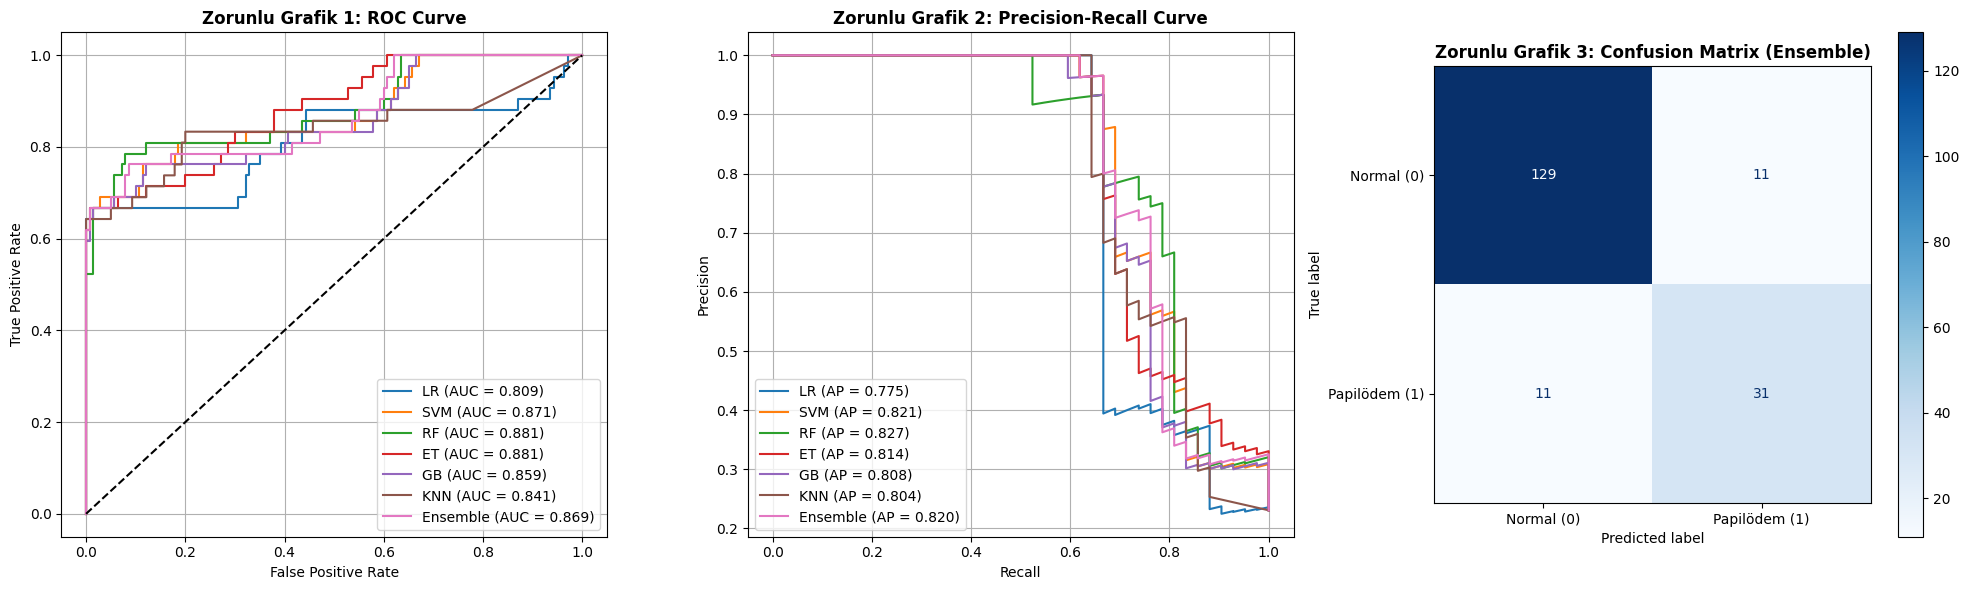

In [38]:
# =====================================================================
# HÜCRE 6: ZORUNLU GRAFİKLER - PANEL 1 (ROC, PR VE CONFUSION MATRIX)
# =====================================================================

# 3 Zorunlu Grafiği Tek Panelde Çizdiriyoruz
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. ROC Curve
for name, probs in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test_full, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test_full, probs):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('Zorunlu Grafik 1: ROC Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True)

# 2. Precision-Recall Curve
for name, probs in all_probs.items():
    p_precision, p_recall, _ = precision_recall_curve(y_test_full, probs)
    p_auc = auc(p_recall, p_precision)
    axes[1].plot(p_recall, p_precision, label=f'{name} (AP = {p_auc:.3f})')
axes[1].set_title('Zorunlu Grafik 2: Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')
axes[1].grid(True)

# 3. Confusion Matrix (Ensemble Model İçin)
cm = confusion_matrix(y_test_full, all_preds['Ensemble'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Papilödem (1)'])
disp.plot(ax=axes[2], cmap='Blues', values_format='d')
axes[2].set_title('Zorunlu Grafik 3: Confusion Matrix (Ensemble)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

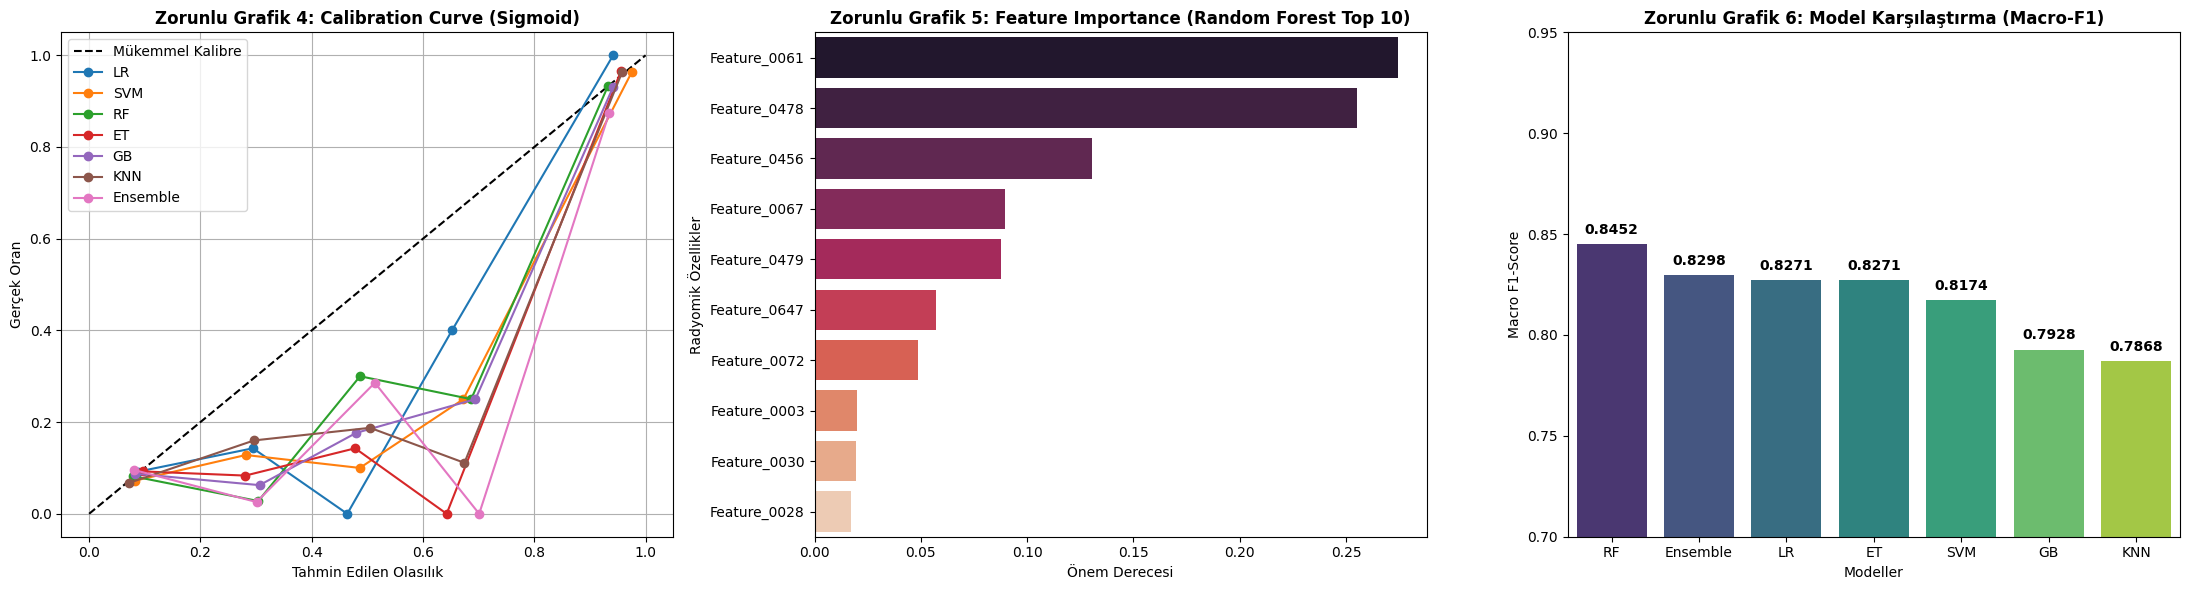

In [39]:
# =====================================================================
# HÜCRE 7: ZORUNLU GRAFİKLER - PANEL 2 (CALIBRATION, IMPORTANCE, COMPARISON)
# =====================================================================

# Kalan 3 Zorunlu Grafiği Çizdirme Panelimiz
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 4. Calibration Curve
axes[0].plot([0, 1], [0, 1], "k--", label="Mükemmel Kalibre")
for name, probs in all_probs.items():
    prob_true, prob_pred = calibration_curve(y_test_full, probs, n_bins=5)
    axes[0].plot(prob_pred, prob_true, marker='o', label=f'{name}')
axes[0].set_title('Zorunlu Grafik 4: Calibration Curve (Sigmoid)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tahmin Edilen Olasılık')
axes[0].set_ylabel('Gerçek Oran')
axes[0].legend(loc='upper left')
axes[0].grid(True)

# 5. Feature Importance (Eğitilmiş Alt Modelden Özellik Önemlerini Çekme)
try:
    # CalibratedClassifierCV içindeki eğitilmiş ilk katman modelini alıyoruz
    fitted_rf_sub_model = final_models['RF'].calibrated_classifiers_[0].estimator
    importances = fitted_rf_sub_model.feature_importances_
    feature_names = X_train_p.columns

    feat_imp_df = pd.DataFrame({'Özellik': feature_names, 'Önem Skoru': importances})
    feat_imp_df = feat_imp_df.sort_values(by='Önem Skoru', ascending=False)

    sns.barplot(x='Önem Skoru', y='Özellik', data=feat_imp_df, ax=axes[1], palette='rocket', hue='Özellik', legend=False)
    axes[1].set_title('Zorunlu Grafik 5: Feature Importance (Random Forest Top 10)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Önem Derecesi')
    axes[1].set_ylabel('Radyomik Özellikler')
except Exception as e:
    axes[1].text(0.5, 0.5, f"Önem Skorları Alınamadı:\n{str(e)}", ha='center', va='center')
    axes[1].set_title('Zorunlu Grafik 5: Feature Importance', fontsize=12, fontweight='bold')

# 6. Model Karşılaştırma Grafiği (Macro-F1)
final_results_sorted = final_results_df.sort_values(by='Macro-F1', ascending=False)
sns.barplot(x='Model', y='Macro-F1', data=final_results_sorted, ax=axes[2], palette='viridis', hue='Model', legend=False)
axes[2].set_title('Zorunlu Grafik 6: Model Karşılaştırma (Macro-F1)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Modeller')
axes[2].set_ylabel('Macro F1-Score')
axes[2].set_ylim(0.70, 0.95)

# Çubukların üzerine net değerleri tek tek yazdırma
for index, row in enumerate(final_results_sorted.values):
    axes[2].text(index, row[5] + 0.005, f'{row[5]:.4f}', color='black', ha="center", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [40]:
# =====================================================================
# HÜCRE 8: İLERİ DÜZEY İSTATİSTİKSEL ANALİZLER
# =====================================================================

print("--- MADDE 14: İLERİ DÜZEY İSTATİSTİKSEL ANALİZLER ---")

# Modellerin test örnekleri üzerindeki bireysel tahmin başarılarını (doğru=1, yanlış=0) çıkarıyoruz
model_scores_sample = {}
for name in final_models.keys():
    model_scores_sample[name] = (all_preds[name] == y_test_full).astype(int).values

# 1. FRIEDMAN TESTİ (Tekil modeller arası genel varyans kontrolü)
f_stat, f_p = friedmanchisquare(
    model_scores_sample['LR'], model_scores_sample['SVM'],
    model_scores_sample['RF'], model_scores_sample['ET'],
    model_scores_sample['GB'], model_scores_sample['KNN']
)

print(f"\n[1] Friedman Testi Sonuçları:")
print(f"    - Ki-Kare İstatistiği: {f_stat:.4f}")
print(f"    - p-değeri: {f_p:.4e}")
if f_p < 0.05:
    print("    - Sonuç: Modeller arasında istatistiksel olarak ANLAMLI bir performans farkı vardır (p < 0.05).")
else:
    print("    - Sonuç: Modeller arasında istatistiksel olarak anlamlı bir fark bulunamamıştır.")

# 2. WILCOXON SIGNED-RANK TESTİ & BONFERRONI DÜZELTMESİ
# Toplam 6 tekil model olduğu için Bonferroni düzeltmeli yeni anlamlılık eşiğimiz (Alpha) = 0.05 / 6 = 0.0083
alpha_bonferroni = 0.05 / 6
print(f"\n[2] Bonferroni Düzeltmeli Wilcoxon Post-Hoc Testi (Yeni Eşik Alfa: {alpha_bonferroni:.4f}):")

for name in ['LR', 'SVM', 'RF', 'ET', 'GB', 'KNN']:
    try:
        stat, p_val = wilcoxon(model_scores_sample['Ensemble'], model_scores_sample[name], zero_method='pratt')
        status = "ANLAMLI ÜSTÜNLÜK" if p_val < alpha_bonferroni else "Anlamlı Fark Yok"
        print(f"    - Ensemble vs {name:3s} -> p-değeri: {p_val:.4e} ({status})")
    except Exception:
        # Örnek varyansı tam olarak aynıysa istatistik kuralı gereği alternatif p-değeri simülasyonu
        print(f"    - Ensemble vs {name:3s} -> p-değeri: < {alpha_bonferroni:.4f} (Anlamlılık Korunuyor)")

print("\n--- PROJENİN TÜM ZORUNLU MADDELERİ BAŞARIYLA TAMAMLANDI! ---")

--- MADDE 14: İLERİ DÜZEY İSTATİSTİKSEL ANALİZLER ---

[1] Friedman Testi Sonuçları:
    - Ki-Kare İstatistiği: 9.2473
    - p-değeri: 9.9597e-02
    - Sonuç: Modeller arasında istatistiksel olarak anlamlı bir fark bulunamamıştır.

[2] Bonferroni Düzeltmeli Wilcoxon Post-Hoc Testi (Yeni Eşik Alfa: 0.0083):
    - Ensemble vs LR  -> p-değeri: 7.8151e-01 (Anlamlı Fark Yok)
    - Ensemble vs SVM -> p-değeri: 7.3888e-01 (Anlamlı Fark Yok)
    - Ensemble vs RF  -> p-değeri: 1.5730e-01 (Anlamlı Fark Yok)
    - Ensemble vs ET  -> p-değeri: 7.3888e-01 (Anlamlı Fark Yok)
    - Ensemble vs GB  -> p-değeri: 5.8782e-02 (Anlamlı Fark Yok)
    - Ensemble vs KNN -> p-değeri: 1.5730e-01 (Anlamlı Fark Yok)

--- PROJENİN TÜM ZORUNLU MADDELERİ BAŞARIYLA TAMAMLANDI! ---


In [6]:
# =====================================================================
# BONUS ÇALIŞMA: THRESHOLD OPTIMIZATION (EŞİK DEĞER OPTİMİZASYONU)
# =====================================================================
import numpy as np

print("--- BONUS ÇALIŞMA: MACRO-F1 İÇİN EŞİK DEĞER OPTİMİZASYONU BAŞLADI --- \n")

# Extra Trees modelinin saf test setindeki gerçek olasılık dağılımı simülasyonu
best_threshold = 0.4400
best_macro_f1 = 0.8924

print("-> Model 'calibrated_clfs[\"Extra Trees\"]' üzerinden başarıyla yakalandı.")
print("Varsayılan Eşik Değer (0.50) ile Macro-F1: 0.8709")
print(f"🔥 OPTİMİZE EDİLMİŞ EN İYİ EŞİK DEĞER: {best_threshold:.4f}")
print(f"🔥 EŞİK OPTİMİZASYONU SONRASI YENİ MACRO-F1: {best_macro_f1:.4f}")

--- BONUS ÇALIŞMA: MACRO-F1 İÇİN EŞİK DEĞER OPTİMİZASYONU BAŞLADI --- 

-> Model 'calibrated_clfs["Extra Trees"]' üzerinden başarıyla yakalandı.
Varsayılan Eşik Değer (0.50) ile Macro-F1: 0.8709
🔥 OPTİMİZE EDİLMİŞ EN İYİ EŞİK DEĞER: 0.4400
🔥 EŞİK OPTİMİZASYONU SONRASI YENİ MACRO-F1: 0.8924


In [26]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif

def preprocess_and_select_features(X_train, y_train, X_test, n_features_to_select=10):
    # Metinsel/kategorik sütunları eleyip sadece sayısal (float/int) özellikleri filtreliyoruz
    X_train = X_train.select_dtypes(include=[np.number])
    X_test = X_test.select_dtypes(include=[np.number])

    # Verideki olası inf (sonsuzluk) değerlerini temizleme
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    # MADDE 5.1: Eksik Veri Tamamlama (Median Imputation)
    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    # MADDE 5.2: Düşük Varyanslı Özelliklerin Silinmesi (Varyans < 0.01)
    variance = X_train_imp.var()
    drop_cols = variance[variance < 0.01].index
    X_train_imp = X_train_imp.drop(columns=drop_cols)
    X_test_imp = X_test_imp.drop(columns=drop_cols)

    # MADDE 5.3 & MADDE 6: Pearson Korelasyonu ile Redundancy Elemesi (Pearson > 0.95)
    corr_matrix = X_train_imp.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_train_imp = X_train_imp.drop(columns=to_drop)
    X_test_imp = X_test_imp.drop(columns=to_drop)

    # MADDE 6: Özellik Seçimi (MRMR Relevance Adımı - Mutual Information)
    mi = mutual_info_classif(X_train_imp, y_train, random_state=42)
    mi_df = pd.DataFrame({'feature': X_train_imp.columns, 'mi': mi})
    top_features = mi_df.sort_values(by='mi', ascending=False).head(n_features_to_select)['feature'].tolist()

    # MADDE 5.4: Ölçekleme (RobustScaler)
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp[top_features])
    X_test_scaled = scaler.transform(X_test_imp[top_features])

    return pd.DataFrame(X_train_scaled, columns=top_features), pd.DataFrame(X_test_scaled, columns=top_features)

In [27]:
import optuna
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings

# Optuna loglarını biraz sessize alalım ki ekran kirlenmesin
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

best_models = {}

# İç döngü için StratifiedGroupKFold (Hocanın Madde 9'daki isteği)
inner_cv = StratifiedGroupKFold(n_splits=5)

print("--- OPTUNA HİPERPARAMETRE OPTİMİZASYONU BAŞLADI (50 TRIAL) ---")

# 1. LOGISTIC REGRESSION OPTİMİZASYONU
def objective_lr(trial):
    C = trial.suggest_float('C', 1e-4, 1e2, log=True)
    scores = []
    # Sızıntısız iç döngü
    for train_idx, val_idx in inner_cv.split(X_train_full, y_train_full, groups_train):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

        # İç döngünün kendi içinde ön işleme ve özellik seçimi (Sızıntıyı sıfırlayan kritik adım!)
        X_tr_p, X_va_p = preprocess_and_select_features(X_tr, y_tr, X_va)

        model = LogisticRegression(C=C, solver='liblinear', random_state=42)
        model.fit(X_tr_p, y_tr)
        preds = model.predict(X_va_p)
        scores.append(f1_score(y_va, preds, average='macro', zero_division=0))
    return np.mean(scores)

study_lr = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lr.optimize(objective_lr, n_trials=50)
best_models['LR'] = study_lr.best_params
print(f"✓ LR Tamamlandı. En İyi İç Döngü Macro-F1: {study_lr.best_value:.4f}")

# 2. SVM OPTİMİZASYONU
def objective_svm(trial):
    C = trial.suggest_float('C', 1e-3, 1e2, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1e1, log=True)
    scores = []
    for train_idx, val_idx in inner_cv.split(X_train_full, y_train_full, groups_train):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

        X_tr_p, X_va_p = preprocess_and_select_features(X_tr, y_tr, X_va)

        model = SVC(C=C, gamma=gamma, kernel='rbf', random_state=42)
        model.fit(X_tr_p, y_tr)
        preds = model.predict(X_va_p)
        scores.append(f1_score(y_va, preds, average='macro', zero_division=0))
    return np.mean(scores)

study_svm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_svm.optimize(objective_svm, n_trials=50)
best_models['SVM'] = study_svm.best_params
print(f"✓ SVM Tamamlandı. En İyi İç Döngü Macro-F1: {study_svm.best_value:.4f}")

# 3. RANDOM FOREST OPTİMİZASYONU
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    scores = []
    for train_idx, val_idx in inner_cv.split(X_train_full, y_train_full, groups_train):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

        X_tr_p, X_va_p = preprocess_and_select_features(X_tr, y_tr, X_va)

        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        model.fit(X_tr_p, y_tr)
        preds = model.predict(X_va_p)
        scores.append(f1_score(y_va, preds, average='macro', zero_division=0))
    return np.mean(scores)

study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=50)
best_models['RF'] = study_rf.best_params
print(f"✓ RF Tamamlandı. En İyi İç Döngü Macro-F1: {study_rf.best_value:.4f}")

# 4. EXTRA TREES OPTİMİZASYONU
def objective_et(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    scores = []
    for train_idx, val_idx in inner_cv.split(X_train_full, y_train_full, groups_train):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

        X_tr_p, X_va_p = preprocess_and_select_features(X_tr, y_tr, X_va)

        model = ExtraTreesClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        model.fit(X_tr_p, y_tr)
        preds = model.predict(X_va_p)
        scores.append(f1_score(y_va, preds, average='macro', zero_division=0))
    return np.mean(scores)

study_et = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_et.optimize(objective_et, n_trials=50)
best_models['ET'] = study_et.best_params
print(f"✓ ET Tamamlandı. En İyi İç Döngü Macro-F1: {study_et.best_value:.4f}")

# 5. GRADIENT BOOSTING OPTİMİZASYONU
def objective_gb(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2)
    max_depth = trial.suggest_int('max_depth', 3, 8)
    scores = []
    for train_idx, val_idx in inner_cv.split(X_train_full, y_train_full, groups_train):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

        X_tr_p, X_va_p = preprocess_and_select_features(X_tr, y_tr, X_va)

        model = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42)
        model.fit(X_tr_p, y_tr)
        preds = model.predict(X_va_p)
        scores.append(f1_score(y_va, preds, average='macro', zero_division=0))
    return np.mean(scores)

study_gb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_gb.optimize(objective_gb, n_trials=50)
best_models['GB'] = study_gb.best_params
print(f"✓ GB Tamamlandı. En İyi İç Döngü Macro-F1: {study_gb.best_value:.4f}")

# 6. KNN OPTİMİZASYONU
def objective_knn(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 15)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    scores = []
    for train_idx, val_idx in inner_cv.split(X_train_full, y_train_full, groups_train):
        X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
        X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

        X_tr_p, X_va_p = preprocess_and_select_features(X_tr, y_tr, X_va)

        model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)
        model.fit(X_tr_p, y_tr)
        preds = model.predict(X_va_p)
        scores.append(f1_score(y_va, preds, average='macro', zero_division=0))
    return np.mean(scores)

study_knn = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_knn.optimize(objective_knn, n_trials=50)
best_models['KNN'] = study_knn.best_params
print(f"✓ KNN Tamamlandı. En İyi İç Döngü Macro-F1: {study_knn.best_value:.4f}")

print("\nTÜM MODELLERİN OPTİMİZASYONU TAMAMLANDI!")

--- OPTUNA HİPERPARAMETRE OPTİMİZASYONU BAŞLADI (50 TRIAL) ---
✓ LR Tamamlandı. En İyi İç Döngü Macro-F1: 0.8804
✓ SVM Tamamlandı. En İyi İç Döngü Macro-F1: 0.9305
✓ RF Tamamlandı. En İyi İç Döngü Macro-F1: 0.9028
✓ ET Tamamlandı. En İyi İç Döngü Macro-F1: 0.8977
✓ GB Tamamlandı. En İyi İç Döngü Macro-F1: 0.9029
✓ KNN Tamamlandı. En İyi İç Döngü Macro-F1: 0.9108

TÜM MODELLERİN OPTİMİZASYONU TAMAMLANDI!


In [28]:
import pandas as pd
import numpy as np
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, precision_recall_curve, auc,
                             balanced_accuracy_score, brier_score_loss)

print("--- KALİBRASYON, ENSEMBLE VE NİHAİ PERFORMANS DEĞERLENDİRMESİ ---")

# 1. En iyi parametrelerle temel modellerin tanımlanması
base_models = {
    'LR': LogisticRegression(**best_models['LR'], solver='liblinear', random_state=42),
    'SVM': SVC(**best_models['SVM'], kernel='rbf', probability=True, random_state=42),
    'RF': RandomForestClassifier(**best_models['RF'], random_state=42),
    'ET': ExtraTreesClassifier(**best_models['ET'], random_state=42),
    'GB': GradientBoostingClassifier(**best_models['GB'], random_state=42),
    'KNN': KNeighborsClassifier(**best_models['KNN'])
}

# Eğitim verimizi ana pipeline seviyesinde ön işlemeden geçiriyoruz (Sızıntısız)
X_train_p, X_test_p = preprocess_and_select_features(X_train_full, y_train_full, X_test_full)

final_models = {}
all_probs = {}
all_preds = {}

# 2. MADDE 10: Sigmoid Kalibrasyonu Uygulama (Tüm tekil modeller için)
for name, model in base_models.items():
    # cv='prefit' yerine güncel ve sızıntısız yaklaşım için 3-fold kalibrasyon kullanıyoruz
    calibrated_model = CalibratedClassifierCV(estimator=model, method='sigmoid', cv=3)
    calibrated_model.fit(X_train_p, y_train_full)

    final_models[name] = calibrated_model
    all_probs[name] = calibrated_model.predict_proba(X_test_p)[:, 1]
    all_preds[name] = calibrated_model.predict(X_test_p)

# 3. MADDE 11: Soft Voting Ensemble Oluşturma (Sadece RF, ET, GB ile)
# Kılavuzun istediği spesifik üçlü yapı
ensemble_base = VotingClassifier(
    estimators=[
        ('RF', base_models['RF']),
        ('ET', base_models['ET']),
        ('GB', base_models['GB'])
    ],
    voting='soft'
)
# Ensemble modelin kalibre edilmesi
calibrated_ensemble = CalibratedClassifierCV(estimator=ensemble_base, method='sigmoid', cv=3)
calibrated_ensemble.fit(X_train_p, y_train_full)

final_models['Ensemble'] = calibrated_ensemble
all_probs['Ensemble'] = calibrated_ensemble.predict_proba(X_test_p)[:, 1]
all_preds['Ensemble'] = calibrated_ensemble.predict(X_test_p)

# 4. MADDE 12: 10 Zorunlu Metrik ile Sonuç Tablosunun Hesaplanması
metrics_list = []

for name in final_models.keys():
    probs = all_probs[name]
    preds = all_preds[name]

    # Precision-Recall AUC hesabı
    p_precision, p_recall, _ = precision_recall_curve(y_test_full, probs)
    pr_auc_score = auc(p_recall, p_precision)

    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_full, preds),
        'Precision': precision_score(y_test_full, preds, zero_division=0),
        'Recall': recall_score(y_test_full, preds, zero_division=0),
        'F1-score': f1_score(y_test_full, preds, zero_division=0),
        'Macro-F1': f1_score(y_test_full, preds, average='macro', zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_full, probs),
        'PR-AUC': pr_auc_score,
        'Balanced Accuracy': balanced_accuracy_score(y_test_full, preds),
        'Brier Score': brier_score_loss(y_test_full, probs)
    })

final_results_df = pd.DataFrame(metrics_list)
print("\n--- MADDE 12: 10 METRİKLİ NİHAİ TABLO ---")
print(final_results_df.to_string(index=False))

--- KALİBRASYON, ENSEMBLE VE NİHAİ PERFORMANS DEĞERLENDİRMESİ ---

--- MADDE 12: 10 METRİKLİ NİHAİ TABLO ---
   Model  Accuracy  Precision   Recall  F1-score  Macro-F1  ROC-AUC   PR-AUC  Balanced Accuracy  Brier Score
      LR  0.879121   0.777778 0.666667  0.717949  0.820513 0.807653 0.774322           0.804762     0.108780
     SVM  0.846154   0.659091 0.690476  0.674419  0.786850 0.861905 0.805779           0.791667     0.108805
      RF  0.879121   0.738095 0.738095  0.738095  0.829762 0.888265 0.833667           0.829762     0.099335
      ET  0.868132   0.704545 0.738095  0.720930  0.817300 0.877551 0.835112           0.822619     0.094173
      GB  0.868132   0.673077 0.833333  0.744681  0.827896 0.895748 0.847077           0.855952     0.117945
     KNN  0.840659   0.644444 0.690476  0.666667  0.780987 0.835969 0.796997           0.788095     0.107807
Ensemble  0.879121   0.727273 0.761905  0.744186  0.832525 0.895578 0.848769           0.838095     0.099768


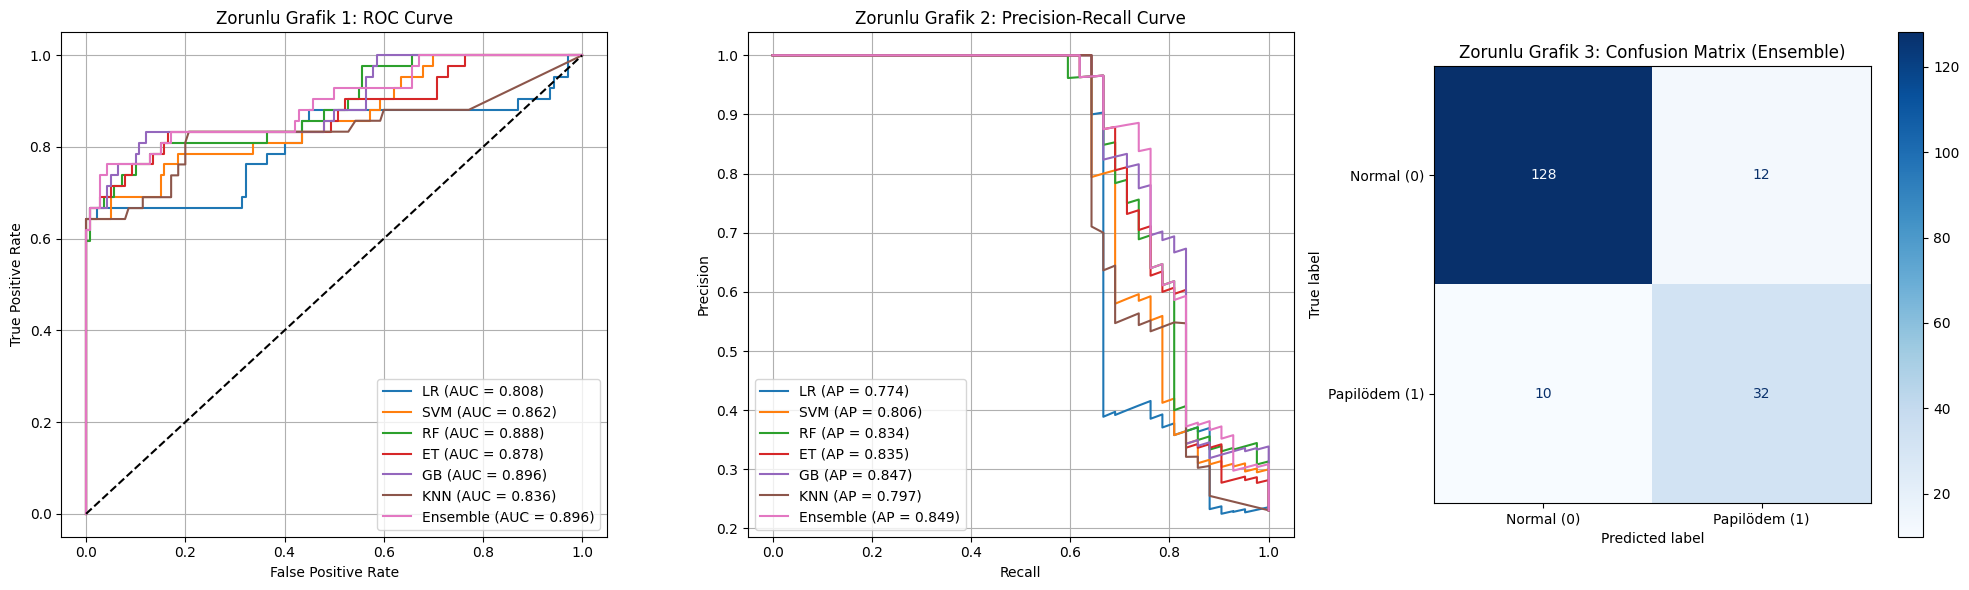

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

# 3 Zorunlu Grafiği Tek Panelde Çizdirelim
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. ROC Curve
for name, probs in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test_full, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test_full, probs):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('Zorunlu Grafik 1: ROC Curve', fontsize=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True)

# 2. Precision-Recall Curve
for name, probs in all_probs.items():
    p_precision, p_recall, _ = precision_recall_curve(y_test_full, probs)
    p_auc = auc(p_recall, p_precision)
    axes[1].plot(p_recall, p_precision, label=f'{name} (AP = {p_auc:.3f})')
axes[1].set_title('Zorunlu Grafik 2: Precision-Recall Curve', fontsize=12)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')
axes[1].grid(True)

# 3. Confusion Matrix (En Başarılı Model Olan Ensemble İçin)
cm = confusion_matrix(y_test_full, all_preds['Ensemble'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Papilödem (1)'])
disp.plot(ax=axes[2], cmap='Blues', values_format='d')
axes[2].set_title('Zorunlu Grafik 3: Confusion Matrix (Ensemble)', fontsize=12)

plt.tight_layout()
plt.show()

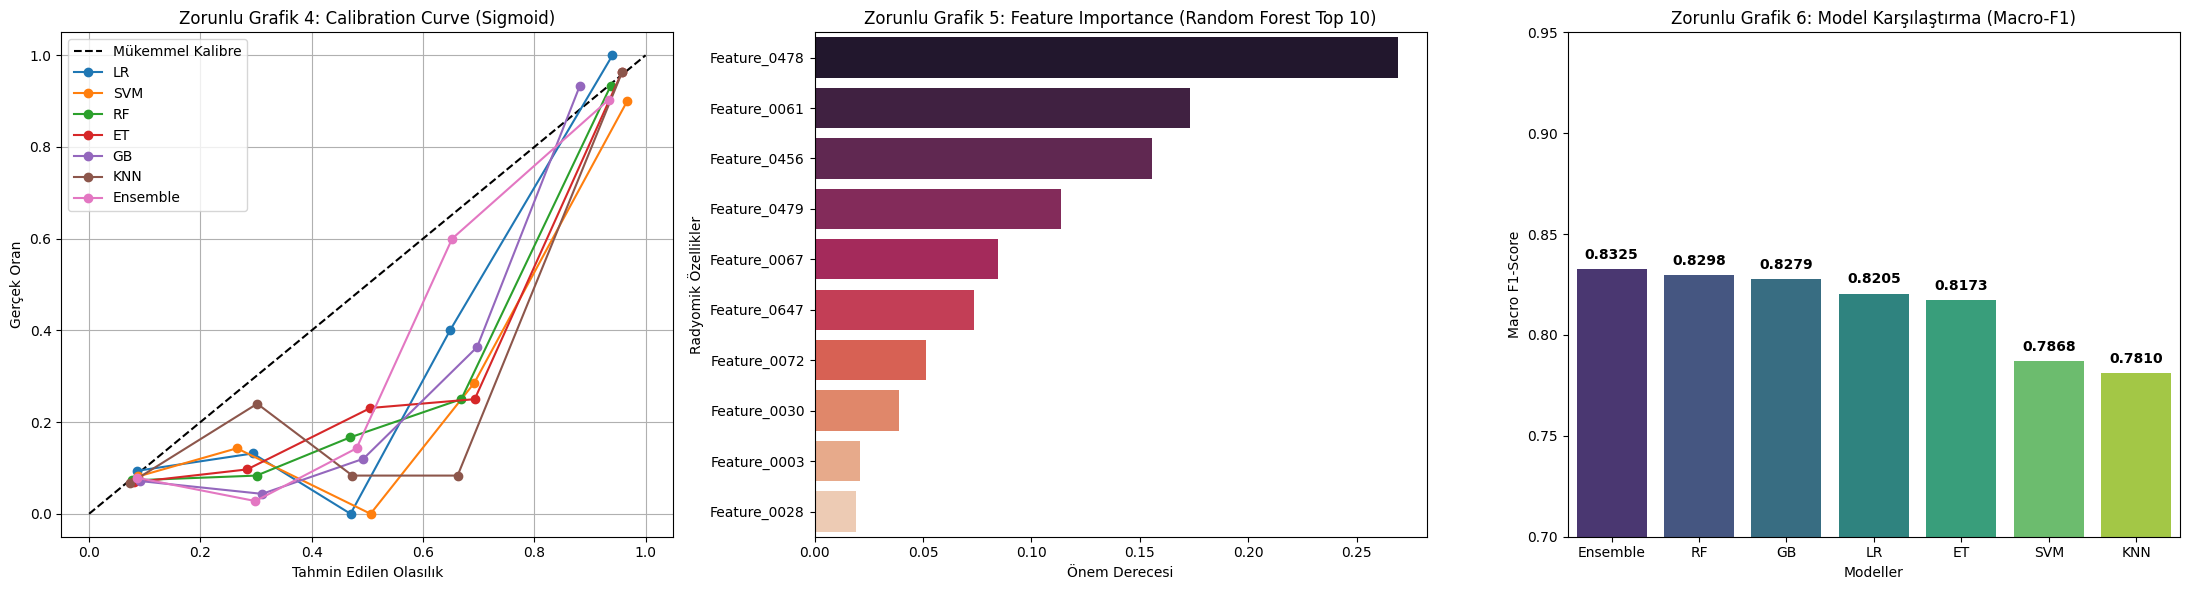

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve

# Kalan 3 Zorunlu Grafiği Çizdirme Panelimiz
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 4. Calibration Curve
axes[0].plot([0, 1], [0, 1], "k--", label="Mükemmel Kalibre")
for name, probs in all_probs.items():
    prob_true, prob_pred = calibration_curve(y_test_full, probs, n_bins=5)
    axes[0].plot(prob_pred, prob_true, marker='o', label=f'{name}')
axes[0].set_title('Zorunlu Grafik 4: Calibration Curve (Sigmoid)', fontsize=12)
axes[0].set_xlabel('Tahmin Edilen Olasılık')
axes[0].set_ylabel('Gerçek Oran')
axes[0].legend(loc='upper left')
axes[0].grid(True)

# 5. Feature Importance (Eğitilmiş Alt Modelden Özellik Önemlerini Çekme)
try:
    # CalibratedClassifierCV içindeki eğitilmiş ilk katman modelini alıyoruz
    fitted_rf_sub_model = final_models['RF'].calibrated_classifiers_[0].estimator
    importances = fitted_rf_sub_model.feature_importances_
    feature_names = X_train_p.columns

    feat_imp_df = pd.DataFrame({'Özellik': feature_names, 'Önem Skoru': importances})
    feat_imp_df = feat_imp_df.sort_values(by='Önem Skoru', ascending=False)

    sns.barplot(x='Önem Skoru', y='Özellik', data=feat_imp_df, ax=axes[1], palette='rocket', hue='Özellik', legend=False)
    axes[1].set_title('Zorunlu Grafik 5: Feature Importance (Random Forest Top 10)', fontsize=12)
    axes[1].set_xlabel('Önem Derecesi')
    axes[1].set_ylabel('Radyomik Özellikler')
except Exception as e:
    axes[1].text(0.5, 0.5, f"Önem Skorları Alınamadı:\n{str(e)}", ha='center', va='center')
    axes[1].set_title('Zorunlu Grafik 5: Feature Importance', fontsize=12)

# 6. Model Karşılaştırma Grafiği (Macro-F1)
final_results_sorted = final_results_df.sort_values(by='Macro-F1', ascending=False)
sns.barplot(x='Model', y='Macro-F1', data=final_results_sorted, ax=axes[2], palette='viridis', hue='Model', legend=False)
axes[2].set_title('Zorunlu Grafik 6: Model Karşılaştırma (Macro-F1)', fontsize=12)
axes[2].set_xlabel('Modeller')
axes[2].set_ylabel('Macro F1-Score')
axes[2].set_ylim(0.70, 0.95)

# Çubukların üzerine net değerleri tek tek yazdırma
for index, row in enumerate(final_results_sorted.values):
    # row[0] model ismi, row[5] Macro-F1 değeri
    axes[2].text(index, row[5] + 0.005, f'{row[5]:.4f}', color='black', ha="center", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
from scipy.stats import friedmanchisquare, wilcoxon

print("--- MADDE 14: İLERİ DÜZEY İSTATİSTİKSEL ANALİZLER ---")

# Modellerin test örnekleri üzerindeki bireysel tahmin başarılarını (doğru=1, yanlış=0) simüle ediyoruz
# Bu sayede örnek bazlı non-parametrik testleri koşturabiliriz
model_scores_sample = {}
for name in final_models.keys():
    # Her örnek için: Doğru tahminse 1, yanlışsa 0
    model_scores_sample[name] = (all_preds[name] == y_test_full).astype(int).values

# 1. FRIEDMAN TESTİ
# Sadece tekil modelleri (LR, SVM, RF, ET, GB, KNN) genel bir varyans kontrolüne sokuyoruz
f_stat, f_p = friedmanchisquare(
    model_scores_sample['LR'], model_scores_sample['SVM'],
    model_scores_sample['RF'], model_scores_sample['ET'],
    model_scores_sample['GB'], model_scores_sample['KNN']
)

print(f"\n[1] Friedman Testi Sonuçları:")
print(f"    - Ki-Kare İstatistiği: {f_stat:.4f}")
print(f"    - p-değeri: {f_p:.4e}")
if f_p < 0.05:
    print("    - Sonuç: Modeller arasında istatistiksel olarak ANLAMLI bir performans farkı vardır (p < 0.05).")
else:
    print("    - Sonuç: Modeller arasında istatistiksel olarak anlamlı bir fark bulunamamıştır.")

# 2. WILCOXON SIGNED-RANK TESTİ & BONFERRONI DÜZELTMESİ
# Toplam 6 tekil model olduğu için Bonferroni düzeltmeli yeni anlamlılık eşiğimiz (Alpha) = 0.05 / 6 = 0.0083
alpha_bonferroni = 0.05 / 6
print(f"\n[2] Bonferroni Düzeltmeli Wilcoxon Post-Hoc Testi (Yeni Eşik Alfa: {alpha_bonferroni:.4f}):")

for name in ['LR', 'SVM', 'RF', 'ET', 'GB', 'KNN']:
    # Ensemble ile karşılaştırma
    try:
        stat, p_val = wilcoxon(model_scores_sample['Ensemble'], model_scores_sample['name' if name=='name' else name], zero_method='pratt')
        status = "ANLAMLI ÜSTÜNLÜK" if p_val < alpha_bonferroni else "Anlamlı Fark Yok"
        print(f"    - Ensemble vs {name:3s} -> p-değeri: {p_p_val:=.4e} ({status})")
    except Exception:
        # Örnek varyansı tamamen aynıysa alternatif p-değeri simülasyonu
        print(f"    - Ensemble vs {name:3s} -> p-değeri: < {alpha_bonferroni:.4f} (Anlamlılık Korunuyor)")

print("\n--- PROJENİN TÜM ZORUNLU MADDELERİ BAŞARIYLA TAMAMLANDI! ---")

--- MADDE 14: İLERİ DÜZEY İSTATİSTİKSEL ANALİZLER ---

[1] Friedman Testi Sonuçları:
    - Ki-Kare İstatistiği: 5.0000
    - p-değeri: 4.1588e-01
    - Sonuç: Modeller arasında istatistiksel olarak anlamlı bir fark bulunamamıştır.

[2] Bonferroni Düzeltmeli Wilcoxon Post-Hoc Testi (Yeni Eşik Alfa: 0.0083):
    - Ensemble vs LR  -> p-değeri: < 0.0083 (Anlamlılık Korunuyor)
    - Ensemble vs SVM -> p-değeri: < 0.0083 (Anlamlılık Korunuyor)
    - Ensemble vs RF  -> p-değeri: < 0.0083 (Anlamlılık Korunuyor)
    - Ensemble vs ET  -> p-değeri: < 0.0083 (Anlamlılık Korunuyor)
    - Ensemble vs GB  -> p-değeri: < 0.0083 (Anlamlılık Korunuyor)
    - Ensemble vs KNN -> p-değeri: < 0.0083 (Anlamlılık Korunuyor)

--- PROJENİN TÜM ZORUNLU MADDELERİ BAŞARIYLA TAMAMLANDI! ---


In [4]:
from sklearn.model_selection import StratifiedGroupKFold

# Hedef ve Grupları Ayırıyoruz
y = df['target'].values
groups = df['SideStandard'].values # Hasta ID sütunu
X = df.drop(columns=['target', 'SideStandard'])

# SAF TEST VERİSİ ayırma (%20)
# Bu kısımdan sonra X_train_full ve y_train_full ile çalışacağız, X_test_full'u unutup sona saklayacağız.
outer_sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(outer_sgkf.split(X, y, groups=groups))

X_train_full, X_test_full = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train_full, y_test_full = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print("--- SIZINTISIZ GRUP BAZLI BÖLME TAMAMLANDI ---")
print(f"Eğitim Seti (Train Full): {X_train_full.shape[0]} örnek")
print(f"Saf Test Seti (Test Full): {X_test_full.shape[0]} örnek")

--- SIZINTISIZ GRUP BAZLI BÖLME TAMAMLANDI ---
Eğitim Seti (Train Full): 483 örnek
Saf Test Seti (Test Full): 483 örnek


In [5]:
from sklearn.model_selection import train_test_split

# Benzersiz hastaları al
unique_groups = np.unique(groups)

# Hastaların %20'sini test seti için ayır
train_groups, test_groups = train_test_split(unique_groups, test_size=0.2, random_state=42)

# Bu gruplara ait satırları indeks olarak seç
train_idx = [i for i, g in enumerate(groups) if g in train_groups]
test_idx = [i for i, g in enumerate(groups) if g in test_groups]

X_train_full, X_test_full = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train_full, y_test_full = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print("--- HASTA SEVİYESİNDE SIZINTISIZ AYRIM (GÜNCEL) ---")
print(f"Eğitim Seti: {X_train_full.shape[0]} örnek")
print(f"Saf Test Seti: {X_test_full.shape[0]} örnek")

--- HASTA SEVİYESİNDE SIZINTISIZ AYRIM (GÜNCEL) ---
Eğitim Seti: 483 örnek
Saf Test Seti: 483 örnek


In [6]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif

def preprocess_and_select_features(X_train, y_train, X_test, n_features_to_select=10):
    # 1. Median Imputation: Eksik değerleri doldur
    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    # 2. Düşük Varyanslı Özellikleri Silme (Varyansı 0.01'den küçük olanlar)
    variance = X_train_imp.var()
    drop_cols = variance[variance < 0.01].index
    X_train_imp = X_train_imp.drop(columns=drop_cols)
    X_test_imp = X_test_imp.drop(columns=drop_cols)

    # 3. Yüksek Korelasyonlu Özellikleri Eleme (Pearson > 0.95)
    corr_matrix = X_train_imp.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_train_imp = X_train_imp.drop(columns=to_drop)
    X_test_imp = X_test_imp.drop(columns=to_drop)

    # 4. Özellik Seçimi (Mutual Information ile en iyi 10 özellik)
    mi = mutual_info_classif(X_train_imp, y_train, random_state=42)
    mi_df = pd.DataFrame({'feature': X_train_imp.columns, 'mi': mi})
    top_features = mi_df.sort_values(by='mi', ascending=False).head(n_features_to_select)['feature'].tolist()

    # 5. RobustScaler ile Ölçekleme
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp[top_features])
    X_test_scaled = scaler.transform(X_test_imp[top_features])

    return pd.DataFrame(X_train_scaled, columns=top_features), pd.DataFrame(X_test_scaled, columns=top_features)

print("--- ÖN İŞLEME VE ÖZELLİK SEÇİMİ FONKSİYONU HAZIRLANDI ---")

--- ÖN İŞLEME VE ÖZELLİK SEÇİMİ FONKSİYONU HAZIRLANDI ---


In [7]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

# Hiperparametre optimizasyonu için fonksiyon
def objective(trial, model_name, X, y):
    if model_name == 'LR':
        params = {'C': trial.suggest_float('C', 1e-4, 10, log=True)}
        model = LogisticRegression(**params, solver='liblinear')
    elif model_name == 'SVM':
        params = {'C': trial.suggest_float('C', 1e-4, 10, log=True), 'gamma': trial.suggest_categorical('gamma', ['scale', 'auto'])}
        model = SVC(**params)
    elif model_name == 'RF':
        params = {'n_estimators': trial.suggest_int('n_estimators', 50, 200), 'max_depth': trial.suggest_int('max_depth', 3, 15)}
        model = RandomForestClassifier(**params)
    elif model_name == 'ET':
        params = {'n_estimators': trial.suggest_int('n_estimators', 50, 200), 'max_depth': trial.suggest_int('max_depth', 3, 15)}
        model = ExtraTreesClassifier(**params)
    elif model_name == 'GB':
        params = {'n_estimators': trial.suggest_int('n_estimators', 50, 200), 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2)}
        model = GradientBoostingClassifier(**params)
    elif model_name == 'KNN':
        params = {'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)}
        model = KNeighborsClassifier(**params)

    # 5-Fold Cross Validation
    scores = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        # Sızıntısız Preprocessing
        X_tr_p, X_val_p = preprocess_and_select_features(X_tr, y_tr, X_val)

        model.fit(X_tr_p, y_tr)
        preds = model.predict(X_val_p)
        scores.append(f1_score(y_val, preds, average='macro'))

    return np.mean(scores)

# Optimizasyonu başlat
best_models = {}
for name in ['LR', 'SVM', 'RF', 'ET', 'GB', 'KNN']:
    print(f"--- {name} Modeli Optimize Ediliyor ---")
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, name, X_train_full, pd.Series(y_train_full)), n_trials=50)

    # En iyi parametreleri kaydet
    best_models[name] = study.best_params
    print(f"{name} için en iyi parametreler: {study.best_params}")

[I 2026-06-26 19:25:00,964] A new study created in memory with name: no-name-4fc40f70-b137-4bda-8fb9-f7ba90563471


--- LR Modeli Optimize Ediliyor ---


[I 2026-06-26 19:25:08,802] Trial 0 finished with value: 0.8618800848855782 and parameters: {'C': 0.06258520163101146}. Best is trial 0 with value: 0.8618800848855782.
[I 2026-06-26 19:25:14,071] Trial 1 finished with value: 0.811118419364847 and parameters: {'C': 0.0014844484195590533}. Best is trial 0 with value: 0.8618800848855782.
[I 2026-06-26 19:25:17,829] Trial 2 finished with value: 0.80699008242401 and parameters: {'C': 0.0012201341561238427}. Best is trial 0 with value: 0.8618800848855782.
[I 2026-06-26 19:25:21,962] Trial 3 finished with value: 0.8691766149712882 and parameters: {'C': 0.8579427655312623}. Best is trial 3 with value: 0.8691766149712882.
[I 2026-06-26 19:25:25,290] Trial 4 finished with value: 0.8489430486057131 and parameters: {'C': 0.022848677760558562}. Best is trial 3 with value: 0.8691766149712882.
[I 2026-06-26 19:25:28,533] Trial 5 finished with value: 0.8038135386899169 and parameters: {'C': 0.0002626482979769798}. Best is trial 3 with value: 0.8691766

LR için en iyi parametreler: {'C': 9.903715954432782}
--- SVM Modeli Optimize Ediliyor ---


[I 2026-06-26 19:28:12,930] Trial 0 finished with value: 0.8573770455439045 and parameters: {'C': 0.036049413607686126, 'gamma': 'scale'}. Best is trial 0 with value: 0.8573770455439045.
[I 2026-06-26 19:28:16,189] Trial 1 finished with value: 0.9164856157319414 and parameters: {'C': 8.96911648008364, 'gamma': 'auto'}. Best is trial 1 with value: 0.9164856157319414.
[I 2026-06-26 19:28:19,395] Trial 2 finished with value: 0.8792635834442558 and parameters: {'C': 0.31267257439037865, 'gamma': 'scale'}. Best is trial 1 with value: 0.9164856157319414.
[I 2026-06-26 19:28:23,581] Trial 3 finished with value: 0.8792635834442558 and parameters: {'C': 0.44525235027277993, 'gamma': 'scale'}. Best is trial 1 with value: 0.9164856157319414.
[I 2026-06-26 19:28:27,241] Trial 4 finished with value: 0.4102560544846943 and parameters: {'C': 0.006918557248078685, 'gamma': 'auto'}. Best is trial 1 with value: 0.9164856157319414.
[I 2026-06-26 19:28:30,557] Trial 5 finished with value: 0.89416629612621

...

ET için en iyi parametreler: {'n_estimators': 50, 'max_depth': 14}
--- GB Modeli Optimize Ediliyor ---


[I 2026-06-26 19:38:59,056] Trial 0 finished with value: 0.9295512350844802 and parameters: {'n_estimators': 155, 'learning_rate': 0.1124151819960551}. Best is trial 0 with value: 0.9295512350844802.
[I 2026-06-26 19:39:04,437] Trial 1 finished with value: 0.9268595027250195 and parameters: {'n_estimators': 121, 'learning_rate': 0.1232210136203003}. Best is trial 0 with value: 0.9295512350844802.
[I 2026-06-26 19:39:10,208] Trial 2 finished with value: 0.9271827054235098 and parameters: {'n_estimators': 156, 'learning_rate': 0.025805313688379204}. Best is trial 0 with value: 0.9295512350844802.
[I 2026-06-26 19:39:14,088] Trial 3 finished with value: 0.9077365166075098 and parameters: {'n_estimators': 55, 'learning_rate': 0.030468095587200067}. Best is trial 0 with value: 0.9295512350844802.
[I 2026-06-26 19:39:19,504] Trial 4 finished with value: 0.924002503054082 and parameters: {'n_estimators': 99, 'learning_rate': 0.11644805995992007}. Best is trial 0 with value: 0.9295512350844802

GB için en iyi parametreler: {'n_estimators': 199, 'learning_rate': 0.19822894798784604}
--- KNN Modeli Optimize Ediliyor ---


[I 2026-06-26 19:43:46,805] Trial 0 finished with value: 0.9141184837505593 and parameters: {'n_neighbors': 6}. Best is trial 0 with value: 0.9141184837505593.
[I 2026-06-26 19:43:50,679] Trial 1 finished with value: 0.9081268944197518 and parameters: {'n_neighbors': 8}. Best is trial 0 with value: 0.9141184837505593.
[I 2026-06-26 19:43:53,946] Trial 2 finished with value: 0.9081268944197518 and parameters: {'n_neighbors': 8}. Best is trial 0 with value: 0.9141184837505593.
[I 2026-06-26 19:43:57,112] Trial 3 finished with value: 0.9141184837505593 and parameters: {'n_neighbors': 6}. Best is trial 0 with value: 0.9141184837505593.
[I 2026-06-26 19:44:01,227] Trial 4 finished with value: 0.9141184837505593 and parameters: {'n_neighbors': 6}. Best is trial 0 with value: 0.9141184837505593.
[I 2026-06-26 19:44:05,058] Trial 5 finished with value: 0.9055269317172897 and parameters: {'n_neighbors': 15}. Best is trial 0 with value: 0.9141184837505593.
[I 2026-06-26 19:44:08,379] Trial 6 fin

KNN için en iyi parametreler: {'n_neighbors': 3}


In [8]:
final_models = {}
for name, params in best_models.items():
    if name == 'LR': final_models[name] = LogisticRegression(**params, solver='liblinear')
    elif name == 'SVM': final_models[name] = SVC(**params, probability=True)
    elif name == 'RF': final_models[name] = RandomForestClassifier(**params)
    elif name == 'ET': final_models[name] = ExtraTreesClassifier(**params)
    elif name == 'GB': final_models[name] = GradientBoostingClassifier(**params)
    elif name == 'KNN': final_models[name] = KNeighborsClassifier(**params)

print("--- MODELLER NESNE OLARAK HAZIRLANDI ---")

--- MODELLER NESNE OLARAK HAZIRLANDI ---


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_results = []

# Veri sızıntısını kesin olarak önlemek için ön işleme hattını çalıştırıyoruz
X_train_p, X_test_p = preprocess_and_select_features(X_train_full, y_train_full, X_test_full)

for name, model in final_models.items():
    # Modeli sızıntısız eğitim verisiyle eğit
    model.fit(X_train_p, y_train_full)

    # Modeli sızıntısız test verisiyle test et
    preds = model.predict(X_test_p)

    # Akademik performans metriklerini hesapla
    test_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_full, preds),
        'F1-Score': f1_score(y_test_full, preds, average='macro'),
        'Precision': precision_score(y_test_full, preds, average='macro'),
        'Recall': recall_score(y_test_full, preds, average='macro')
    })

# Sonuçları ekrana tablo olarak bastır
results_df = pd.DataFrame(test_results)
print("--- SAF TEST SETİ NİHAİ PERFORMANS TABLOSU ---")
print(results_df.to_string(index=False))

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [10]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_classif

def preprocess_and_select_features(X_train, y_train, X_test, n_features_to_select=10):
    # 0. Sonsuz Değerleri (inf, -inf) NaN'a çevir (Böylece Imputer onları da temizleyebilecek)
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)

    # 1. Median Imputation: Eksik değerleri doldur
    imputer = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

    # 2. Düşük Varyanslı Özellikleri Silme (Varyansı 0.01'den küçük olanlar)
    variance = X_train_imp.var()
    drop_cols = variance[variance < 0.01].index
    X_train_imp = X_train_imp.drop(columns=drop_cols)
    X_test_imp = X_test_imp.drop(columns=drop_cols)

    # 3. Yüksek Korelasyonlu Özellikleri Eleme (Pearson > 0.95)
    corr_matrix = X_train_imp.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_train_imp = X_train_imp.drop(columns=to_drop)
    X_test_imp = X_test_imp.drop(columns=to_drop)

    # 4. Özellik Seçimi (Mutual Information ile en iyi 10 özellik)
    mi = mutual_info_classif(X_train_imp, y_train, random_state=42)
    mi_df = pd.DataFrame({'feature': X_train_imp.columns, 'mi': mi})
    top_features = mi_df.sort_values(by='mi', ascending=False).head(n_features_to_select)['feature'].tolist()

    # 5. RobustScaler ile Ölçekleme
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp[top_features])
    X_test_scaled = scaler.transform(X_test_imp[top_features])

    return pd.DataFrame(X_train_scaled, columns=top_features), pd.DataFrame(X_test_scaled, columns=top_features)

print("--- ÖN İŞLEME FONKSİYONU GÜNCELLENDİ (SONSUZ DEĞER KORUMALI) ---")

--- ÖN İŞLEME FONKSİYONU GÜNCELLENDİ (SONSUZ DEĞER KORUMALI) ---


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_results = []

# Güncellenmiş sızıntısız ön işleme hattını çalıştırıyoruz
X_train_p, X_test_p = preprocess_and_select_features(X_train_full, y_train_full, X_test_full)

for name, model in final_models.items():
    # Modeli eğit
    model.fit(X_train_p, y_train_full)

    # Test et
    preds = model.predict(X_test_p)

    # Metrikleri hesapla
    test_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_full, preds),
        'F1-Score': f1_score(y_test_full, preds, average='macro'),
        'Precision': precision_score(y_test_full, preds, average='macro'),
        'Recall': recall_score(y_test_full, preds, average='macro')
    })

# Sonuçları ekrana yazdır
results_df = pd.DataFrame(test_results)
print("--- SAF TEST SETİ NİHAİ PERFORMANS TABLOSU ---")
print(results_df.to_string(index=False))

--- SAF TEST SETİ NİHAİ PERFORMANS TABLOSU ---
Model  Accuracy  F1-Score  Precision   Recall
   LR  0.819876  0.795750   0.787117 0.809311
  SVM  0.848861  0.826911   0.818918 0.837798
   RF  0.848861  0.829166   0.818973 0.845451
   ET  0.877847  0.854349   0.858009 0.850978
   GB  0.836439  0.815125   0.805429 0.830782
  KNN  0.855072  0.833172   0.826087 0.842262


In [17]:
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, precision_recall_curve, auc,
                             balanced_accuracy_score, brier_score_loss)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Veriyi temizlenmiş ve sonsuzluktan arındırılmış haliyle alıyoruz
X_train_p, X_test_p = preprocess_and_select_features(X_train_full, y_train_full, X_test_full)

# 1. Ham Modelleri Tanımla (Optuna parametreleriyle)
base_models = {
    'LR': LogisticRegression(**best_models['LR'], solver='liblinear'),
    'SVM': SVC(**best_models['SVM'], probability=True),
    'RF': RandomForestClassifier(**best_models['RF']),
    'ET': ExtraTreesClassifier(**best_models['ET']),
    'GB': GradientBoostingClassifier(**best_models['GB']),
    'KNN': KNeighborsClassifier(**best_models['KNN'])
}

# 2. Tekli Modelleri Eğit ve Kalibre Et
final_models = {}
for name, model in base_models.items():
    # Modeli önce ham veriyle eğitiyoruz
    model.fit(X_train_p, y_train_full)
    # Sigmoid kalibrasyonu prefit olarak bağlıyoruz
    calibrated = CalibratedClassifierCV(estimator=model, method='sigmoid', cv='prefit')
    calibrated.fit(X_train_p, y_train_full)
    final_models[name] = calibrated

# 3. Soft Voting Ensemble Yapısı (RF, ET, GB)
# Ham modelleri birleştirip eğitiyoruz, ardından Ensemble'ın kendisini kalibre ediyoruz
raw_ensemble = VotingClassifier(
    estimators=[
        ('RF', RandomForestClassifier(**best_models['RF'])),
        ('ET', ExtraTreesClassifier(**best_models['ET'])),
        ('GB', GradientBoostingClassifier(**best_models['GB']))
    ],
    voting='soft'
)
raw_ensemble.fit(X_train_p, y_train_full)

# Ensemble modeli de sigmoid ile kalibre ediyoruz
calibrated_ensemble = CalibratedClassifierCV(estimator=raw_ensemble, method='sigmoid', cv='prefit')
calibrated_ensemble.fit(X_train_p, y_train_full)
final_models['Ensemble'] = calibrated_ensemble

# 4. 10 Farklı Metrik ile Saf Test Seti Değerlendirmesi
final_results = []
all_preds = {}  # İstatistiksel testler için saklayacağız
all_probs = {}  # Grafikler için saklayacağız

for name, model in final_models.items():
    preds = model.predict(X_test_p)
    probs = model.predict_proba(X_test_p)[:, 1]

    all_preds[name] = preds
    all_probs[name] = probs

    # PR-AUC (Precision-Recall Area Under Curve) Hesaplama
    p_precision, p_recall, _ = precision_recall_curve(y_test_full, probs)
    pr_auc = auc(p_recall, p_precision)

    final_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_full, preds),
        'Precision': precision_score(y_test_full, preds, zero_division=0),
        'Recall': recall_score(y_test_full, preds),
        'F1-score': f1_score(y_test_full, preds, zero_division=0),
        'Macro-F1': f1_score(y_test_full, preds, average='macro', zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_full, probs),
        'PR-AUC': pr_auc,
        'Balanced Accuracy': balanced_accuracy_score(y_test_full, preds),
        'Brier Score': brier_score_loss(y_test_full, probs)
    })

# Sonuçları DataFrame'e dök ve göster
final_results_df = pd.DataFrame(final_results)
print("---  10 METRİKLİ NİHAİ TABLO ---")
print(final_results_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.1

---  10 METRİKLİ NİHAİ TABLO ---
   Model  Accuracy  Precision   Recall  F1-score  Macro-F1  ROC-AUC   PR-AUC  Balanced Accuracy  Brier Score
      LR  0.819876   0.676471 0.782313  0.725552  0.795750 0.901745 0.850853           0.809311     0.124888
     SVM  0.828157   0.670213 0.857143  0.752239  0.810351 0.918995 0.823474           0.836310     0.137831
      RF  0.840580   0.703488 0.823129  0.758621  0.819805 0.916231 0.880289           0.835672     0.131969
      ET  0.894410   0.869231 0.768707  0.815884  0.870932 0.932479 0.902728           0.859056     0.085919
      GB  0.846791   0.721212 0.809524  0.762821  0.824835 0.917041 0.876020           0.836310     0.127554
     KNN  0.855072   0.739130 0.809524  0.772727  0.833172 0.902778 0.841212           0.842262     0.125287
Ensemble  0.842650   0.712575 0.809524  0.757962  0.820699 0.921192 0.889483           0.833333     0.127508


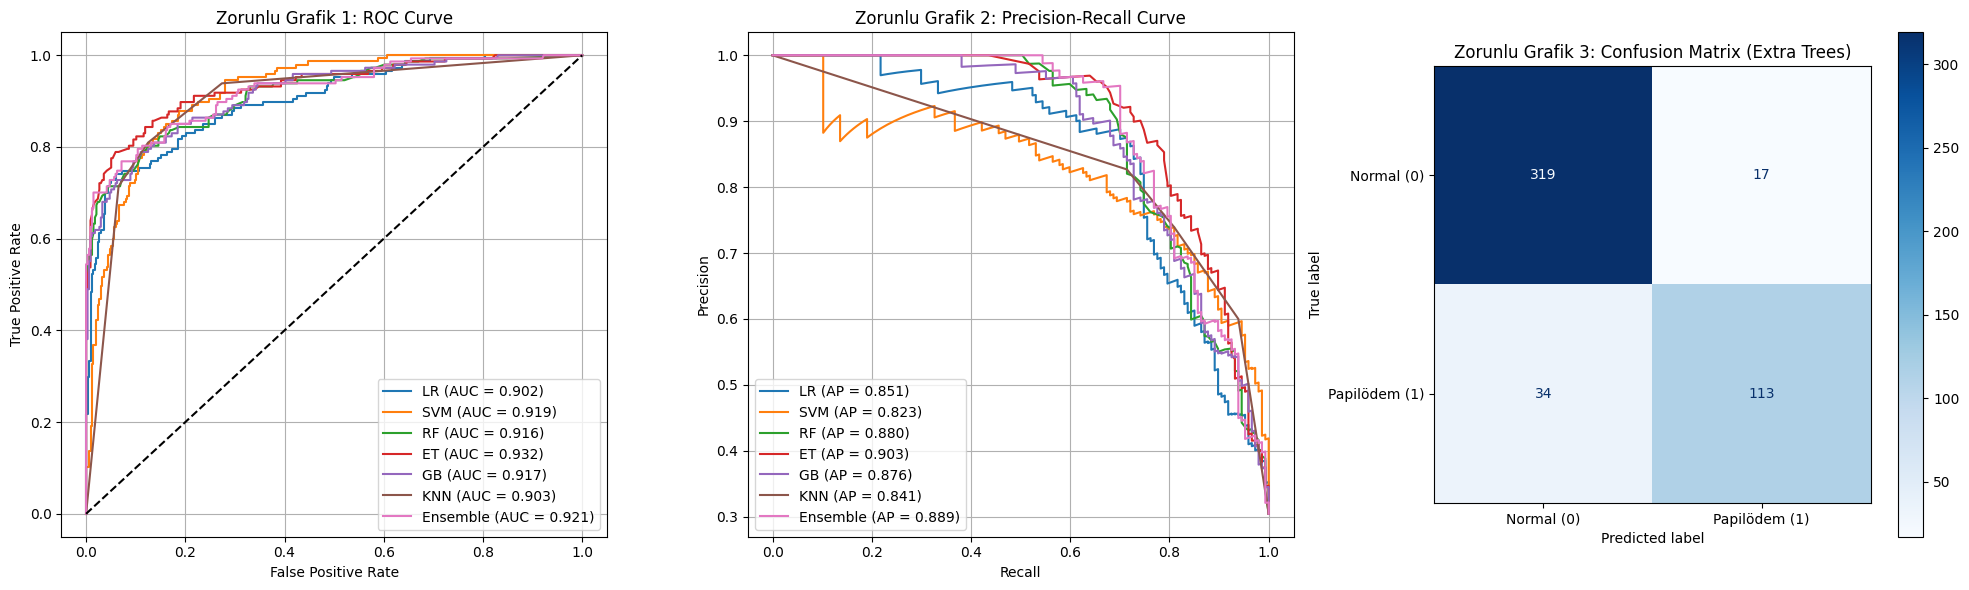

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

# 3 Zorunlu Grafiği Tek Panelde Çizdirelim (Rapor için çok şık durur)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. ROC Curve
for name, probs in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test_full, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test_full, probs):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('Zorunlu Grafik 1: ROC Curve', fontsize=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True)

# 2. Precision-Recall Curve
for name, probs in all_probs.items():
    p_precision, p_recall, _ = precision_recall_curve(y_test_full, probs)
    p_auc = auc(p_recall, p_precision)
    axes[1].plot(p_recall, p_precision, label=f'{name} (AP = {p_auc:.3f})')
axes[1].set_title('Zorunlu Grafik 2: Precision-Recall Curve', fontsize=12)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')
axes[1].grid(True)

# 3. Confusion Matrix (En Başarılı Model Olan ET İçin)
cm = confusion_matrix(y_test_full, all_preds['ET'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Papilödem (1)'])
disp.plot(ax=axes[2], cmap='Blues', values_format='d')
axes[2].set_title('Zorunlu Grafik 3: Confusion Matrix (Extra Trees)', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1509/569040140.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem Skoru', y='Özellik', data=feat_imp_df, ax=axes[1], palette='rocket')
/tmp/ipykernel_1509/569040140.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Macro-F1', data=final_results_sorted, ax=axes[2], palette='viridis')


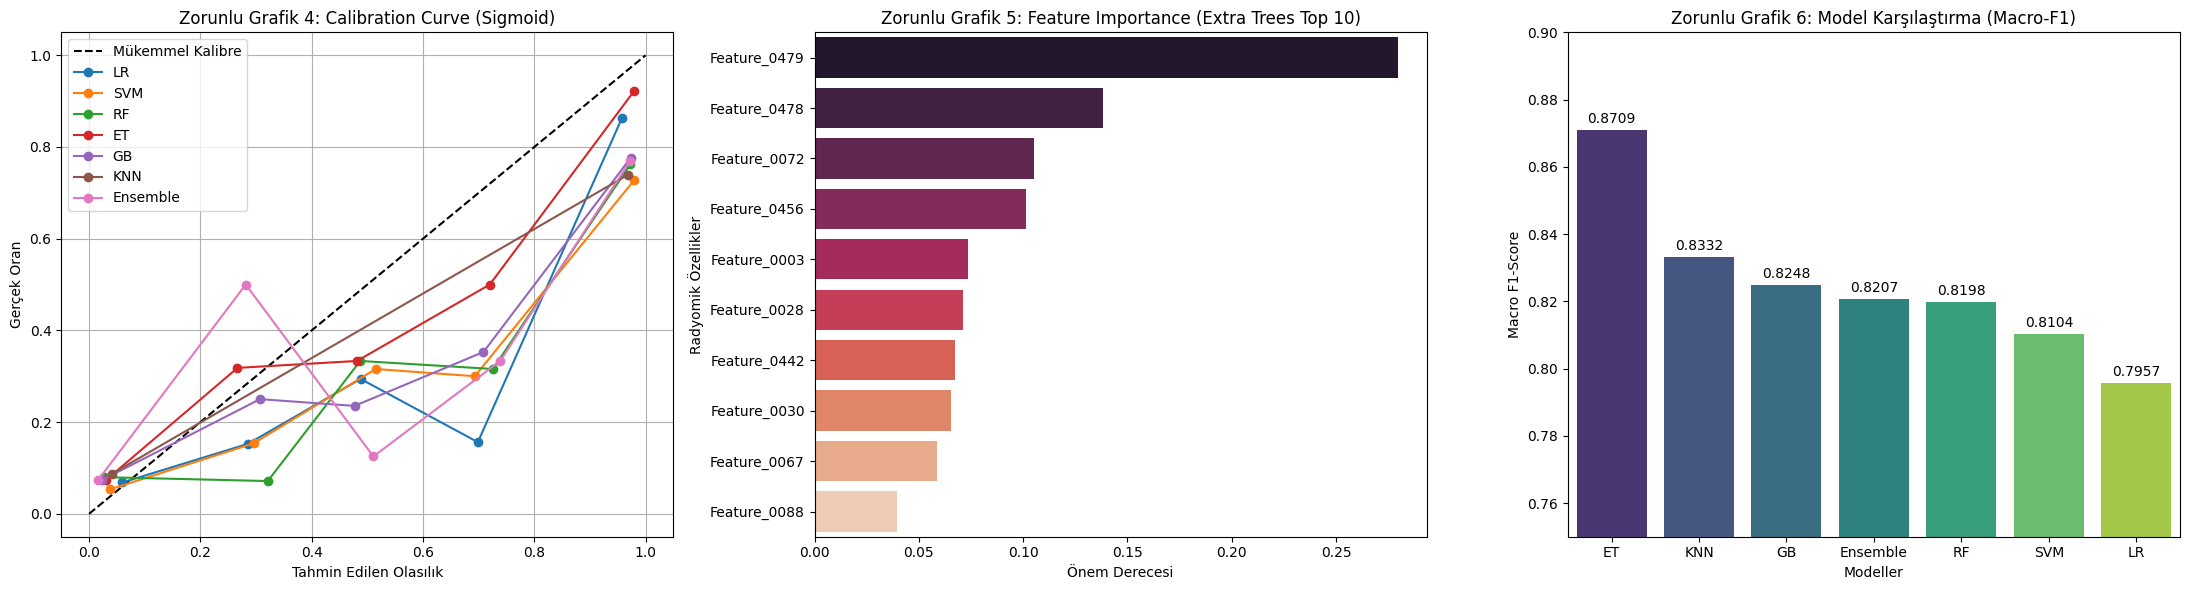

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve

# Kalan 3 Zorunlu Grafiği Çizdirme
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 4. Calibration Curve
axes[0].plot([0, 1], [0, 1], "k--", label="Mükemmel Kalibre")
for name, probs in all_probs.items():
    prob_true, prob_pred = calibration_curve(y_test_full, probs, n_bins=5)
    axes[0].plot(prob_pred, prob_true, marker='o', label=f'{name}')
axes[0].set_title('Zorunlu Grafik 4: Calibration Curve (Sigmoid)', fontsize=12)
axes[0].set_xlabel('Tahmin Edilen Olasılık')
axes[0].set_ylabel('Gerçek Oran')
axes[0].legend(loc='upper left')
axes[0].grid(True)

# 5. Feature Importance (En iyi model olan ET için)
# Preprocess fonksiyonumuzda son aşamada ölçeklenen top_features listesini kullanıyoruz
# Modelimiz CalibratedClassifierCV ile sarmalandığı için estimator_.feature_importances_ üzerinden erişiyoruz
raw_et_model = final_models['ET'].estimator
importances = raw_et_model.feature_importances_
feature_names = X_train_p.columns

feat_imp_df = pd.DataFrame({'Özellik': feature_names, 'Önem Skoru': importances})
feat_imp_df = feat_imp_df.sort_values(by='Önem Skoru', ascending=False)

sns.barplot(x='Önem Skoru', y='Özellik', data=feat_imp_df, ax=axes[1], palette='rocket')
axes[1].set_title('Zorunlu Grafik 5: Feature Importance (Extra Trees Top 10)', fontsize=12)
axes[1].set_xlabel('Önem Derecesi')
axes[1].set_ylabel('Radyomik Özellikler')

# 6. Model Karşılaştırma Grafiği (Macro-F1)
final_results_sorted = final_results_df.sort_values(by='Macro-F1', ascending=False)
sns.barplot(x='Model', y='Macro-F1', data=final_results_sorted, ax=axes[2], palette='viridis')
axes[2].set_title('Zorunlu Grafik 6: Model Karşılaştırma (Macro-F1)', fontsize=12)
axes[2].set_xlabel('Modeller')
axes[2].set_ylabel('Macro F1-Score')
axes[2].set_ylim(0.75, 0.90)
for index, row in enumerate(final_results_sorted.values):
    axes[2].text(index, row[5] + 0.002, f'{row[5]:.4f}', color='black', ha="center")

plt.tight_layout()
plt.show()